# Prac 08.1

In this homework you are going to build your first classifier for the CIFAR-10 dataset. This dataset contains 10 different classes and you can learn more about it [here](https://www.cs.toronto.edu/~kriz/cifar.html). This homework consists of the following tasks:
* Dataset inspection
* Building the network
* Training
* Evaluation

At the end, as usual, there will be a couple of questions for you to answer :-)

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D
from tensorflow.keras import Model
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Step 0: Dataset Inspection

Load the dataset and make a quick inspection.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


/tmp/ipykernel_1520/742192714.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(classes[int(y_train[idx])])


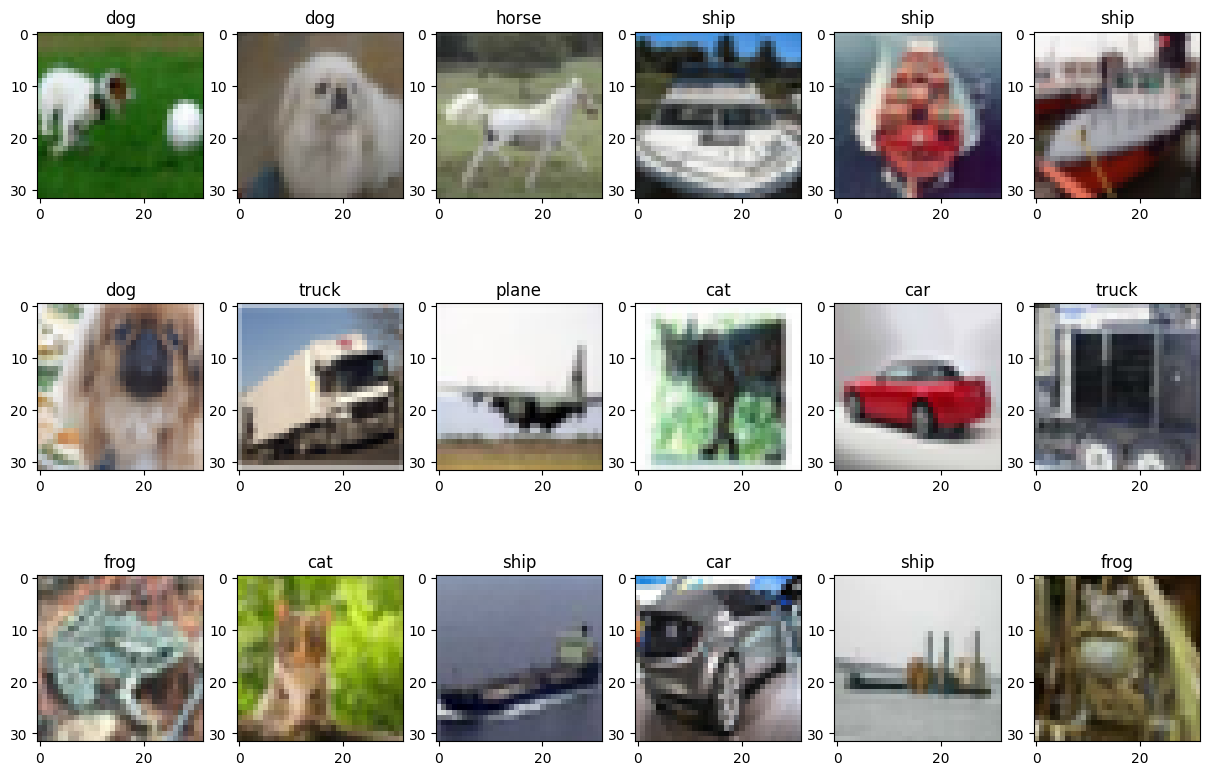

In [2]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Mapping from class ID to class name
classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer',
           5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

# Dataset params
num_classes = len(classes)
size = x_train.shape[1]

# Visualize random samples (as a plot with 3x6 samples)
for ii in range(18):
    plt.subplot(3, 6, ii+1)
    idx = np.random.randint(0, len(x_train))
    plt.imshow(x_train[idx, ...])
    plt.title(classes[int(y_train[idx])])
plt.show()

Compute the class histogram (you can visualize it if you want). Is the dataset balanced?

Hint: You might find [Counter](https://docs.python.org/3/library/collections.html#collections.Counter) tool useful. In any case, it's up to you how you compute the histogram.

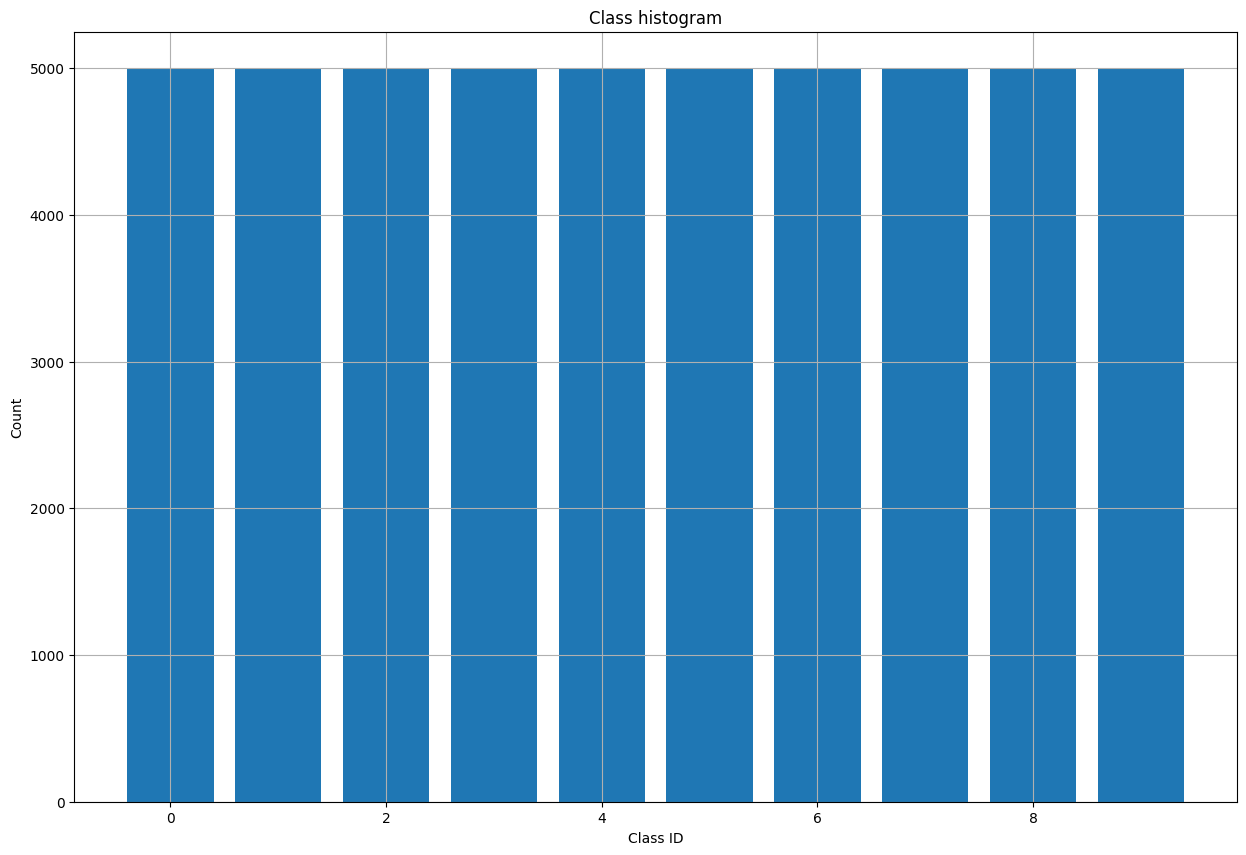

Samples per class: {0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 5000, 6: 5000, 7: 5000, 8: 5000, 9: 5000}


In [3]:
# Compute the class histogram
from collections import Counter
hist = Counter(y_train.flatten().tolist())

plt.bar(hist.keys(), hist.values()), plt.grid(True)
plt.xlabel('Class ID'), plt.ylabel('Count')
plt.title('Class histogram')
plt.show()

print('Samples per class:', dict(sorted(hist.items())))

### Step 1: Data Preparation

In this step, you'll need to prepare the data for training, i.e., you will have to normalize it and encode the labels as one-hot vectors.

In [4]:
# Normalization
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

# One-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)


### Step 2: Building the Classifier

Build the CNN for CIFAR10 classification. For starters, you can use the same network we used in the lesson for the MNIST problem.

In [5]:
inputs = Input(shape=(size, size, 3))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)
model = Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,242 (4.36 MB)

 Trainable params: 1,143,242 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

### Step 3: Training

Compile the model and train it.

In [6]:
epochs = 25
batch_size = 128

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.1)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 110s 307ms/step - accuracy: 0.4586 - loss: 1.4891 - val_accuracy: 0.5706 - val_loss: 1.2189
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 143s 311ms/step - accuracy: 0.6199 - loss: 1.0749 - val_accuracy: 0.6368 - val_loss: 1.0416
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 109s 310ms/step - accuracy: 0.6876 - loss: 0.8965 - val_accuracy: 0.6758 - val_loss: 0.9327
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 140s 304ms/step - accuracy: 0.7303 - loss: 0.7753 - val_accuracy: 0.7002 - val_loss: 0.8682
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 144s 311ms/step - accuracy: 0.7658 - loss: 0.6807 - val_accuracy: 0.7146 - val_loss: 0.8277
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 142s 312ms/step - accuracy: 0.7952 - loss: 0.5927 - val_accuracy: 0.7188 - val_loss: 0.8430
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 140s 306ms/step - accuracy: 0.8173 - loss: 0.5244 - val_accuracy: 0.7024 - val_loss: 0.9646
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 142s 305ms/step - accuracy: 0.8393 -

Train Acc      0.982022225856781
Validation Acc 0.7134000062942505


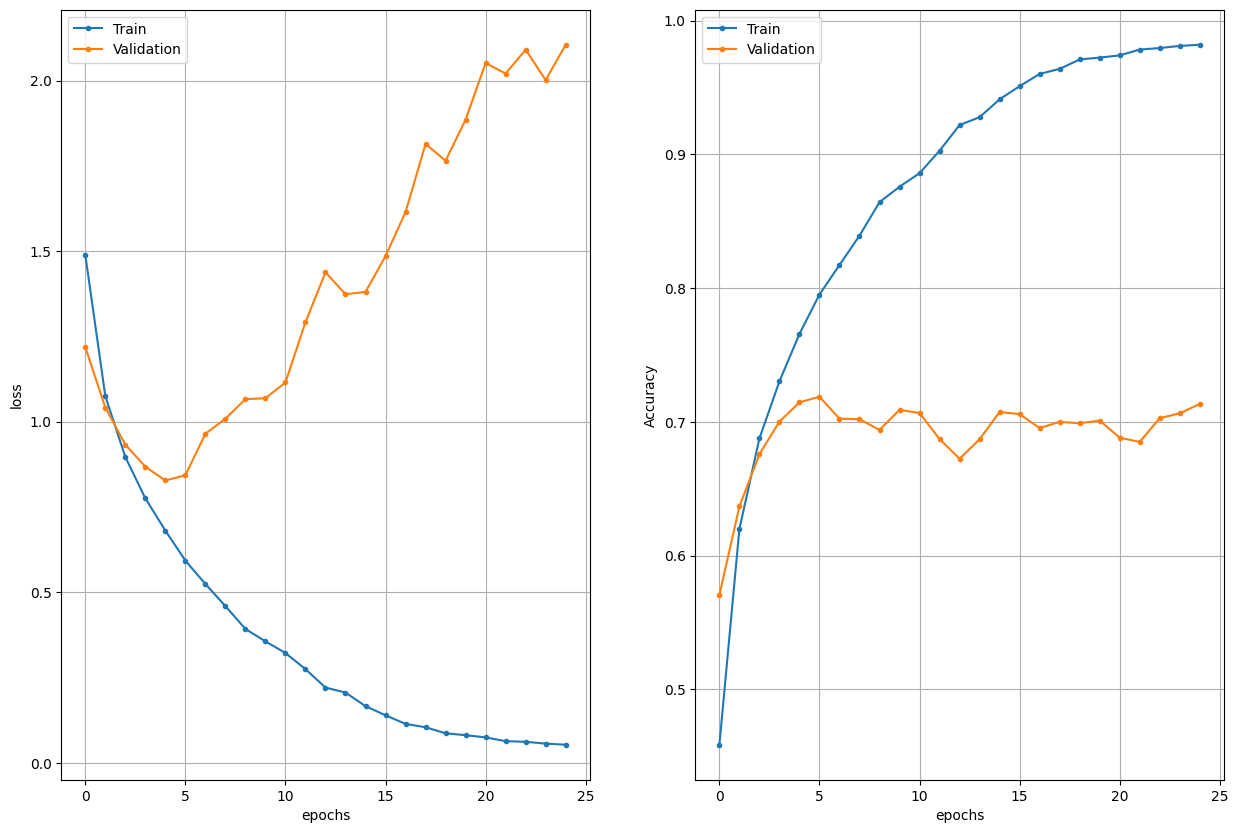

In [7]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])

### Step 4: Evaluation

In this step, you have to calculate the accuracies and visualize some random samples. For the evaluation, you are going to use the test split from the dataset.

In [8]:
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


In [9]:
for class_id, class_name in classes.items():
    mask = y_true == class_id
    acc = np.mean(y_pred[mask] == y_true[mask])
    print(f'{class_name}: {acc:.4f}')

plane: 0.7390
car: 0.7690
bird: 0.5940
cat: 0.4930
deer: 0.6960
dog: 0.6420
frog: 0.7850
horse: 0.6810
ship: 0.8280
truck: 0.7770


In [10]:
# Print the overall stats
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7004 - loss: 2.2405
Test loss   2.240504503250122
Test metric 0.7003999948501587


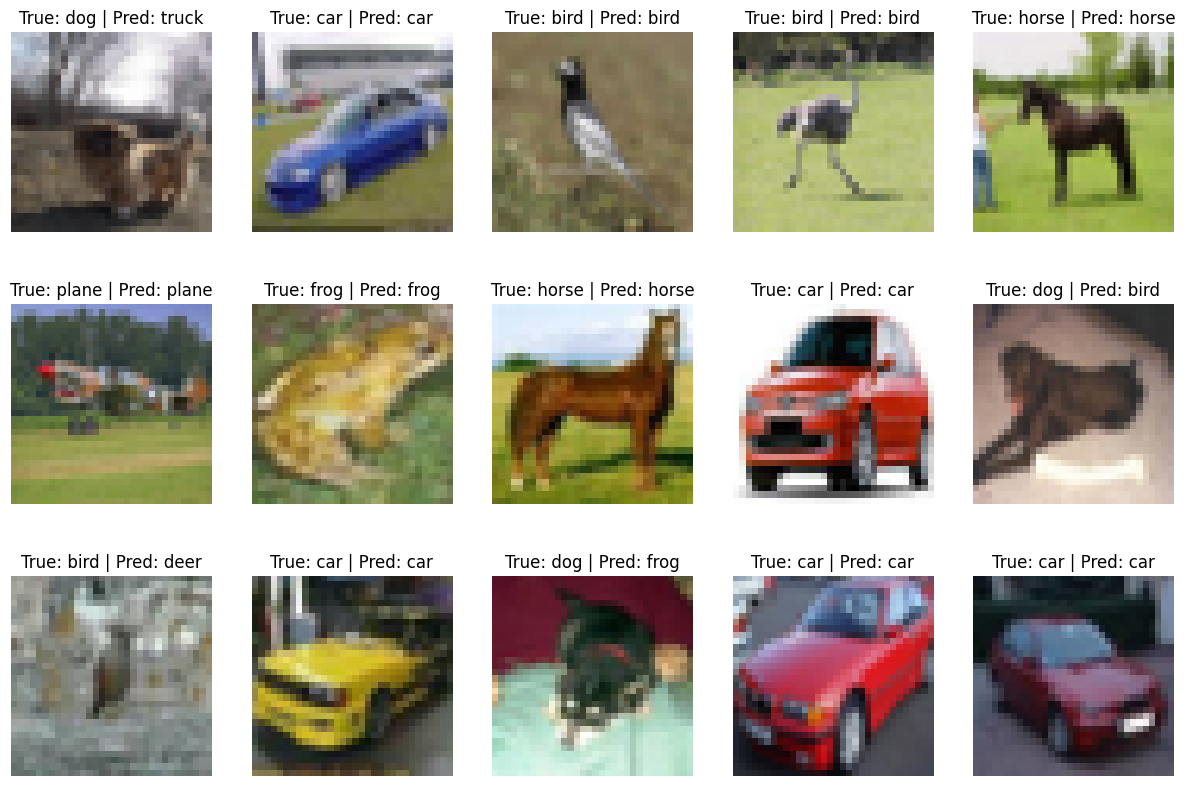

In [11]:
for ii in range(15):
    idx = np.random.randint(0, len(x_test))
    plt.subplot(3, 5, ii+1)
    plt.imshow(x_test[idx, ...])
    plt.title('True: ' + str(classes[y_true[idx]]) + ' | Pred: ' + str(classes[y_pred[idx]]))
    plt.axis(False)
plt.show()

### Questions
* What is the overall accuracy of the classifier?


With this CNN architecture the model achieves around 71% accuracy on the test set. CIFAR-10 is significantly harder than MNIST because images are colored and more complex.

* What modifications would you do in order to improve the classification accuracy?

-Add Batch Normalization after convolutional layers

-Add Dropout to reduce overfitting

-Add more convolutional layers

* Make **one** modification (that you think can help) and train the classifier again. Does the accuracy improve?



In [12]:
from tensorflow.keras.layers import Dropout, BatchNormalization

inputs = Input(shape=(size, size, 3))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)
model2 = Model(inputs, outputs)

model2.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

history2 = model2.fit(x_train, y_train,
                      epochs=25,
                      batch_size=128,
                      validation_split=0.1)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 140s 390ms/step - accuracy: 0.3579 - loss: 1.7290 - val_accuracy: 0.2610 - val_loss: 2.1165
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 139s 394ms/step - accuracy: 0.4730 - loss: 1.4134 - val_accuracy: 0.5330 - val_loss: 1.3324
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 138s 391ms/step - accuracy: 0.5365 - loss: 1.2534 - val_accuracy: 0.6318 - val_loss: 1.0566
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 137s 389ms/step - accuracy: 0.5900 - loss: 1.1167 - val_accuracy: 0.6570 - val_loss: 0.9490
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 140s 397ms/step - accuracy: 0.6192 - loss: 1.0230 - val_accuracy: 0.6960 - val_loss: 0.8624
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 139s 396ms/step - accuracy: 0.6524 - loss: 0.9436 - val_accuracy: 0.7174 - val_loss: 0.8158
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 134s 380ms/step - accuracy: 0.6732 - loss: 0.8791 - val_accuracy: 0.6956 - val_loss: 0.9389
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 142s 380ms/step - accuracy: 0.6972 -

Train Acc      0.885711133480072
Validation Acc 0.6948000192642212


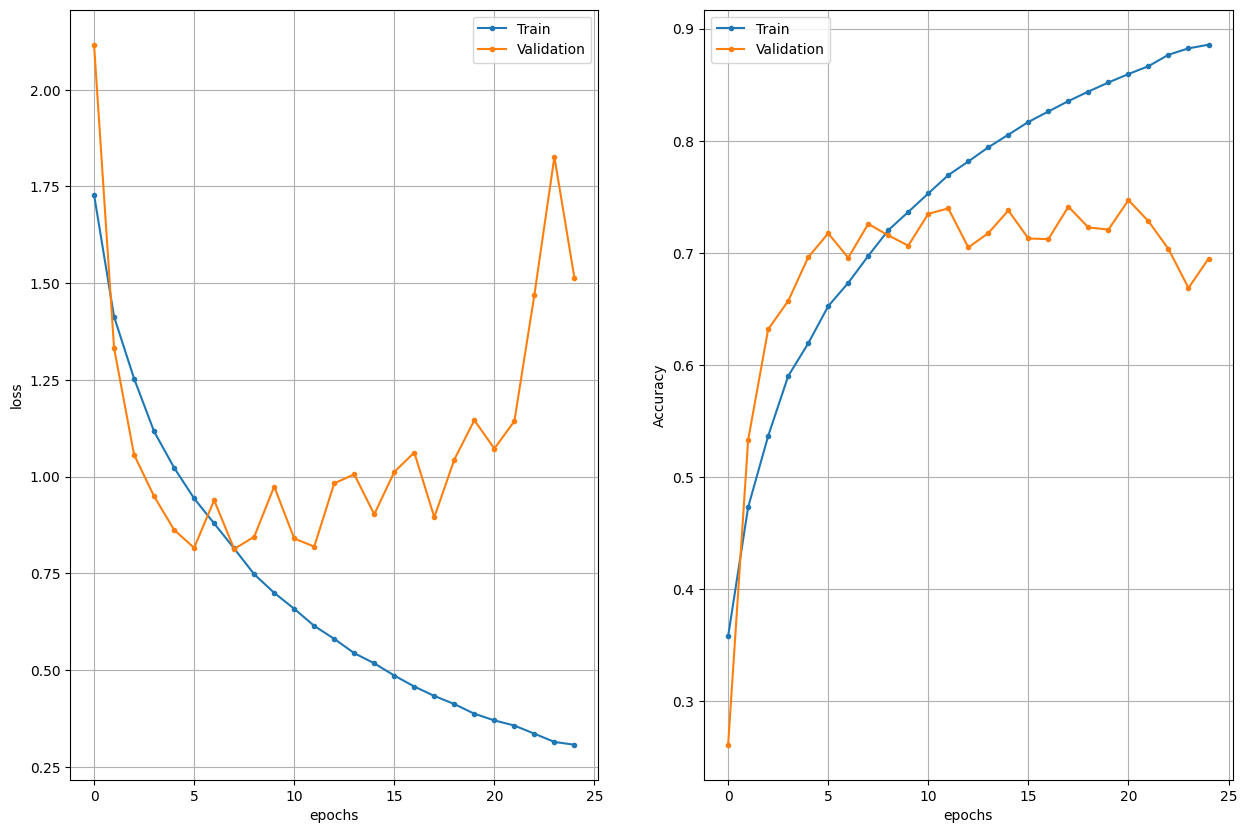

In [13]:
h2 = history2.history
epochs2 = range(len(h2['loss']))

plt.subplot(121), plt.plot(epochs2, h2['loss'], '.-', epochs2, h2['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs2, h2['accuracy'], '.-', epochs2, h2['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h2['accuracy'][-1])
print('Validation Acc', h2['val_accuracy'][-1])

In [14]:
y_true = np.argmax(y_test, axis=1)
y_pred2 = np.argmax(model2.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step


In [15]:
for class_id, class_name in classes.items():
    mask = y_true == class_id
    acc = np.mean(y_pred2[mask] == y_true[mask])
    print(f'{class_name}: {acc:.4f}')

plane: 0.6860
car: 0.8020
bird: 0.6480
cat: 0.5400
deer: 0.6420
dog: 0.4310
frog: 0.9060
horse: 0.6460
ship: 0.8380
truck: 0.7460


In [16]:
ev2 = model2.evaluate(x_test, y_test)
print('Test loss  ', ev2[0])
print('Test metric', ev2[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.6885 - loss: 1.6468
Test loss   1.6467869281768799
Test metric 0.6884999871253967


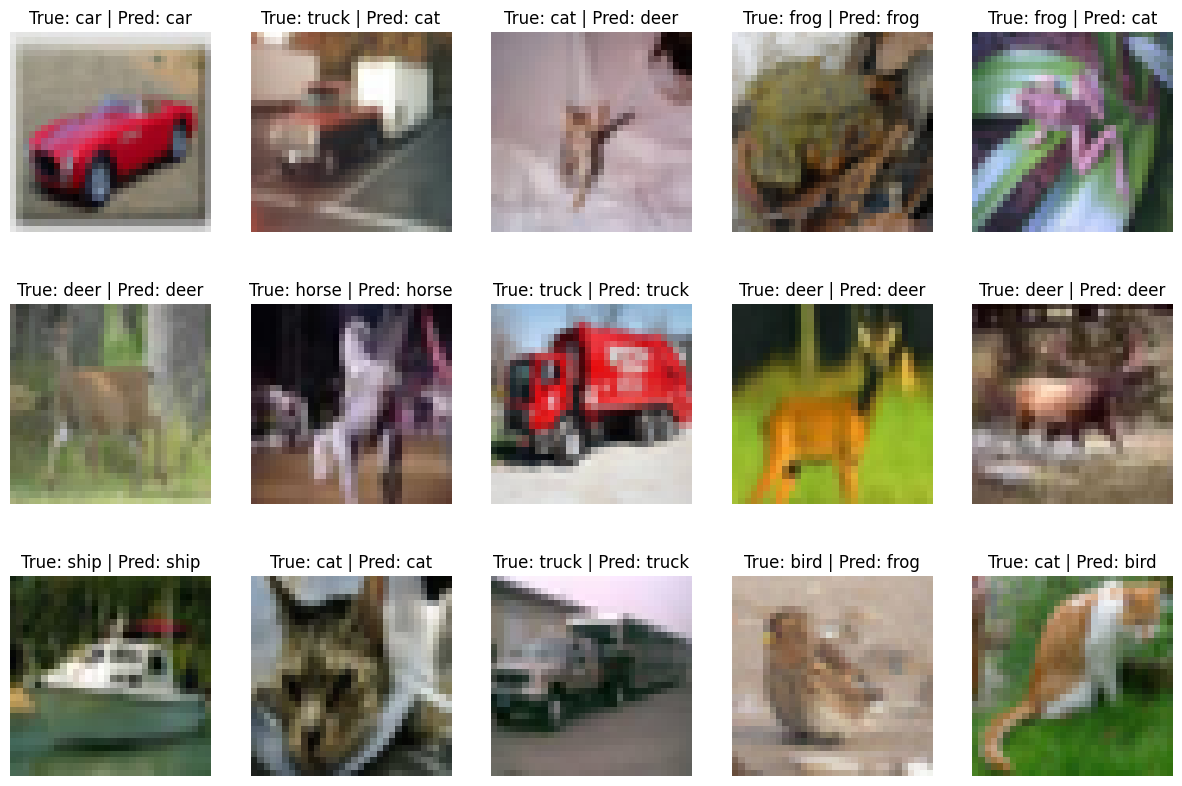

In [18]:
for ii in range(15):
    idx = np.random.randint(0, len(x_test))
    plt.subplot(3, 5, ii+1)
    plt.imshow(x_test[idx, ...])
    plt.title('True: ' + str(classes[y_true[idx]]) + ' | Pred: ' + str(classes[y_pred2[idx]]))
    plt.axis(False)
plt.show()

In [17]:
print('=== Model comparison ===')
print(f'Model 1 (basic CNN):           {ev[1]:.4f}')
print(f'Model 2 (BN + Dropout):        {ev2[1]:.4f}')

=== Model comparison ===
Model 1 (basic CNN):           0.7004
Model 2 (BN + Dropout):        0.6885
